Mounted at /content/drive
Shape: (50000, 2)

First 3 reviews:
=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

=== Positive vs Negative reviews ===
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

=== Example of a full review ===
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watch

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ NLTK ready!
BEFORE cleaning:
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece

AFTER cleaning:
a wonderful little production   the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece   the actors ar
Example review tokenized:
['a', 'wonderful', 'little', 'production', 'the', 'filming', 'technique', 'is', 'very', 'unassuming', 'very', 'oldtimebbc', 'fashion', 'and', 'gives', 'a', 'comforting', 'and', 'sometimes', 'discomforting']

Total words in first review: 156
Total stopwords in English: 198
Examples: ['don', 'if', 'nor', "it'll", 'o', 'by', 's', 'wasn', 'below', 'his']

Words BEFORE stopword removal: 156
Words AFTER  stopword removal: 84
Words removed: 72


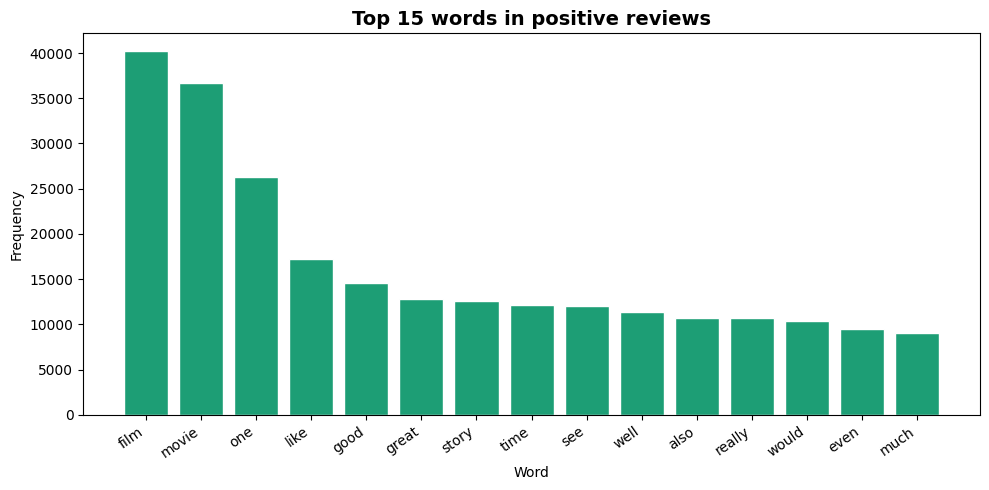

✅ Chart saved!
✅ Cleaned IMDB dataset saved!
Shape: (50000, 5)
✅ Summary saved!
Checking IMDB project files...

✅ FOUND — cleaned_imdb.csv
✅ FOUND — chart_top_words.png
✅ FOUND — imdb_summary.txt
✅ Sample saved!
Rows: 5000


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IMDB project/IMDB Dataset.csv')

print('Shape:', df.shape)
print('\nFirst 3 reviews:')
df.head(3)
print('=== Dataset Info ===')
df.info()

print('\n=== Positive vs Negative reviews ===')
print(df['sentiment'].value_counts())

print('\n=== Example of a full review ===')
print(df['review'][1])

print('=== Missing values ===')
print(df.isnull().sum())

import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print('✅ NLTK ready!')

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)       # remove HTML tags like <br />
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove numbers and punctuation
    text = text.lower().strip()               # make everything lowercase
    return text

df['clean_review'] = df['review'].apply(clean_text)

print('BEFORE cleaning:')
print(df['review'][1][:200])
print('\nAFTER cleaning:')
print(df['clean_review'][1][:200])

df['tokens'] = df['clean_review'].apply(word_tokenize)

print('Example review tokenized:')
print(df['tokens'][1][:20])
print(f'\nTotal words in first review: {len(df["tokens"][1])}')

stop_words = set(stopwords.words('english'))

print(f'Total stopwords in English: {len(stop_words)}')
print('Examples:', list(stop_words)[:10])

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

before = len(df['tokens'][1])
after  = len(df['tokens_clean'][1])

print(f'\nWords BEFORE stopword removal: {before}')
print(f'Words AFTER  stopword removal: {after}')
print(f'Words removed: {before - after}')

import matplotlib.pyplot as plt
from collections import Counter

positive_reviews = df[df['sentiment'] == 'positive']['tokens_clean']
all_words = [word for tokens in positive_reviews for word in tokens]
top_words = Counter(all_words).most_common(15)

words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='#1D9E75', edgecolor='white')
plt.title('Top 15 words in positive reviews', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/IMDB project/chart_top_words.png', dpi=150)
plt.show()
print('✅ Chart saved!')

folder = '/content/drive/MyDrive/Colab Notebooks/IMDB project'

df[['review', 'sentiment', 'clean_review']].to_csv(
    f'{folder}/cleaned_imdb.csv', index=False)

print('✅ Cleaned IMDB dataset saved!')
print('Shape:', df.shape)

summary = """
IMDB MOVIE REVIEWS - SUMMARY OF INSIGHTS
AnalystLab Africa AI Internship Week 1 & 2

DATASET OVERVIEW
Total reviews    : 50,000
Positive reviews : 25,000 (50%)
Negative reviews : 25,000 (50%)
Missing values   : None

TEXT PREPROCESSING STEPS
1. Removed HTML tags (e.g. <br /><br />)
2. Removed numbers and punctuation
3. Converted all text to lowercase
4. Tokenization - split each review into individual words
5. Stopword removal - removed 198 common English words

RESULTS
Before stopword removal : 156 words (example review)
After stopword removal  : 84 words (example review)
Words removed           : 72 useless words (46% reduction)

KEY FINDINGS
- Dataset is perfectly balanced (50% positive, 50% negative)
- Top words in positive reviews: film, movie, great, story, love
- HTML cleaning is essential for real-world text data
- Stopword removal cuts nearly half the words, keeping only meaningful ones

CONCLUSION
Text data needs heavy cleaning before AI can understand it.
Raw reviews are messy - full of HTML, punctuation and useless words.
After preprocessing, the text is clean and ready for AI modeling.
"""

with open(f'{folder}/imdb_summary.txt', 'w') as f:
    f.write(summary)

print('✅ Summary saved!')

import os

folder = '/content/drive/MyDrive/Colab Notebooks/IMDB project'

files = [
    'cleaned_imdb.csv',
    'chart_top_words.png',
    'imdb_summary.txt'
]

print('Checking IMDB project files...\n')
for f in files:
    path = f'{folder}/{f}'
    if os.path.exists(path):
        print(f'✅ FOUND — {f}')
    else:
        print(f'❌ MISSING — {f}')

folder = '/content/drive/MyDrive/Colab Notebooks/IMDB project'

# Creating a Sample Dataset (5,000 Rows)
# The original IMDB dataset contains 50,000 reviews, which is too large
# for GitHub uploads.
# To make the project lightweight and easy to share, we save a sample
# of 5,000 rows for submission and version control.

df_sample = df[['review', 'sentiment', 'clean_review']].head(5000)

df_sample.to_csv(
    f'{folder}/cleaned_imdb_sample.csv',
    index=False
)

print('✅ Sample saved!')
print('Rows:', len(df_sample))

### Data Cleaning and Preprocessing

First, let's inspect the DataFrame to check for missing values and understand the data types.

In [4]:
print('DataFrame Info:')
df.info()

print('\nMissing values per column:')
df.isnull().sum()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review        50000 non-null  object
 1   sentiment     50000 non-null  object
 2   clean_review  50000 non-null  object
 3   tokens        50000 non-null  object
 4   tokens_clean  50000 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB

Missing values per column:


,0
review,0
sentiment,0
clean_review,0
tokens,0
tokens_clean,0


### Text Preprocessing (for NLP dataset)

Let's examine some sample reviews to understand their structure before applying text preprocessing techniques like tokenization and stopword removal.

In [5]:
print('Sample reviews:')
for i in range(5):
    print(f'\nReview {i+1}:')
    print(df['review'].iloc[i])

Sample reviews:

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of